# Simple 2-Hot Encoding Regression for Stop-Signal Task

This notebook implements a simplified encoding scheme:
- **Direction**: GO_L or GO_R (2 features)
- **Trial Type**: GO, STOP_SSD1-4, CONT_SSD1-4 (9 features)
- **Total**: 11 features with 2-hot encoding

## Encoding Examples
- GO left: [GO_L=1, GO_R=0, GO=1, rest=0]
- GO right: [GO_L=0, GO_R=1, GO=1, rest=0]
- STOP SSD4 right: [GO_L=0, GO_R=1, GO=0, STOP_SSD4=1, rest=0]
- CONT SSD2 left: [GO_L=1, GO_R=0, GO=0, CONT_SSD2=1, rest=0]

## Analysis Pipeline
1. Filter to successful trials only
2. Fit Lasso regression
3. PCA on all beta vectors together
4. Visualize 3D projections of GO and STOP SSD2 trials

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from sklearn.linear_model import LassoCV
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from concurrent.futures import ProcessPoolExecutor, as_completed
import multiprocessing as mp
import warnings
warnings.filterwarnings('ignore')

# Import project modules
import sys
sys.path.append('..')
from cell_analysis import Cell
from session_class import Session

# Import parallel processing helpers
from parallel_helpers import fit_single_cell_worker

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## Configuration

In [2]:
# Analysis configuration
config = {
    # Data parameters
    'data_path': '../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl',
    'session_id': 'fi211115a',  # Good multi-cell session
    
    # Time window parameters
    'epok': [0, 150],  # Analysis window relative to stop_cue (ms)
    'bin_size': 50,    # Bin size for spike counts (ms)
    
    # Regression parameters
    'n_splits': 100,   # Number of half-splits for stability
    'alpha_cv_folds': 5,  # Cross-validation folds for alpha selection
    'random_state': 42,
    
    # Trial filtering
    'success_only': True,  # Only use successful trials
    
    # Parallel processing
    'n_workers': max(1, mp.cpu_count() - 2),  # Leave 2 cores free
}

## 1. Data Loading and Filtering

In [3]:
# Load data
print("Loading data...")
cell_df = pd.read_pickle(config['data_path'])
print(f"Loaded {len(cell_df):,} cell-trial combinations")

# Filter to specific session
session_data = cell_df[cell_df['trial_session'] == config['session_id']]
print(f"\nSession {config['session_id']}:")
print(f"  - {session_data['cell_ID'].nunique()} cells")
print(f"  - {len(session_data['trial_number'].unique())} trials")

# Filter to successful trials only
if config['success_only']:
    session_data = session_data[session_data['trial_failed'] == False]
    print(f"\nAfter filtering to successful trials: {len(session_data['trial_number'].unique())} trials")

# Create session
session = Session(session_data, verbose=True)
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nAfter filtering: {session.n_cells} cells")

Loading data...
Loaded 770,705 cell-trial combinations

Session fi211115a:
  - 53 cells
  - 960 trials

After filtering to successful trials: 819 trials
Session fi211115a initialized:
  - Number of cells: 53
  - Total trials: 819
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

After filtering: 53 cells


## 2. Build Simple 2-Hot Design Matrix

Features:
- **Direction**: GO_L, GO_R
- **Trial Type**: GO, STOP_SSD1-4, CONT_SSD1-4

In [4]:
def build_simple_design_matrix(session_data, config):
    """
    Build 2-hot design matrix with simple encoding.
    
    Returns:
    --------
    X : ndarray (n_trials, n_features)
        Design matrix
    feature_names : list
        Names of features/regressors
    trial_info : DataFrame
        Trial metadata for alignment
    """
    # Define feature names
    direction_features = ['GO_L', 'GO_R']
    trial_type_features = ['GO']
    
    # Add STOP features (SSD1-4, successful only)
    for ssd in [1, 2, 3, 4]:
        trial_type_features.append(f'STOP_SSD{ssd}')
    
    # Add CONT features (SSD1-4, successful only)
    for ssd in [1, 2, 3, 4]:
        trial_type_features.append(f'CONT_SSD{ssd}')
    
    feature_names = direction_features + trial_type_features
    n_features = len(feature_names)
    
    print(f"Design matrix: {n_features} features")
    print(f"  Direction: {len(direction_features)}")
    print(f"  Trial type: {len(trial_type_features)}")
    print(f"  Features: {feature_names}")
    
    # Get unique trials
    trials = session_data.drop_duplicates(subset='trial_number').copy()
    n_trials = len(trials)
    
    # Initialize design matrix
    X = np.zeros((n_trials, n_features))
    
    # Build feature index mapping
    feature_idx = {name: i for i, name in enumerate(feature_names)}
    
    # Fill design matrix
    for i, (_, trial) in enumerate(trials.iterrows()):
        # Direction
        dir_feature = 'GO_L' if trial['dir'] == 180 else 'GO_R'
        X[i, feature_idx[dir_feature]] = 1
        
        # Trial type
        if trial['type'] == 'GO':
            X[i, feature_idx['GO']] = 1
        elif trial['type'] == 'CONT':
            ssd_num = int(trial['ssd_number'])
            X[i, feature_idx[f'CONT_SSD{ssd_num}']] = 1
        elif trial['type'] == 'STOP':
            ssd_num = int(trial['ssd_number'])
            X[i, feature_idx[f'STOP_SSD{ssd_num}']] = 1
    
    # Verify each row has exactly 2 ones
    row_sums = X.sum(axis=1)
    assert np.all(row_sums == 2), f"Design matrix error: rows should sum to 2, got {np.unique(row_sums)}"
    
    print(f"✓ Design matrix built: {X.shape}")
    print(f"  Feature usage: min={X.sum(axis=0).min():.0f}, max={X.sum(axis=0).max():.0f} trials")
    
    return X, feature_names, trials

# Build design matrix
X, feature_names, trial_info = build_simple_design_matrix(session.data, config)

Design matrix: 11 features
  Direction: 2
  Trial type: 9
  Features: ['GO_L', 'GO_R', 'GO', 'STOP_SSD1', 'STOP_SSD2', 'STOP_SSD3', 'STOP_SSD4', 'CONT_SSD1', 'CONT_SSD2', 'CONT_SSD3', 'CONT_SSD4']
✓ Design matrix built: (819, 11)
  Feature usage: min=3, max=519 trials


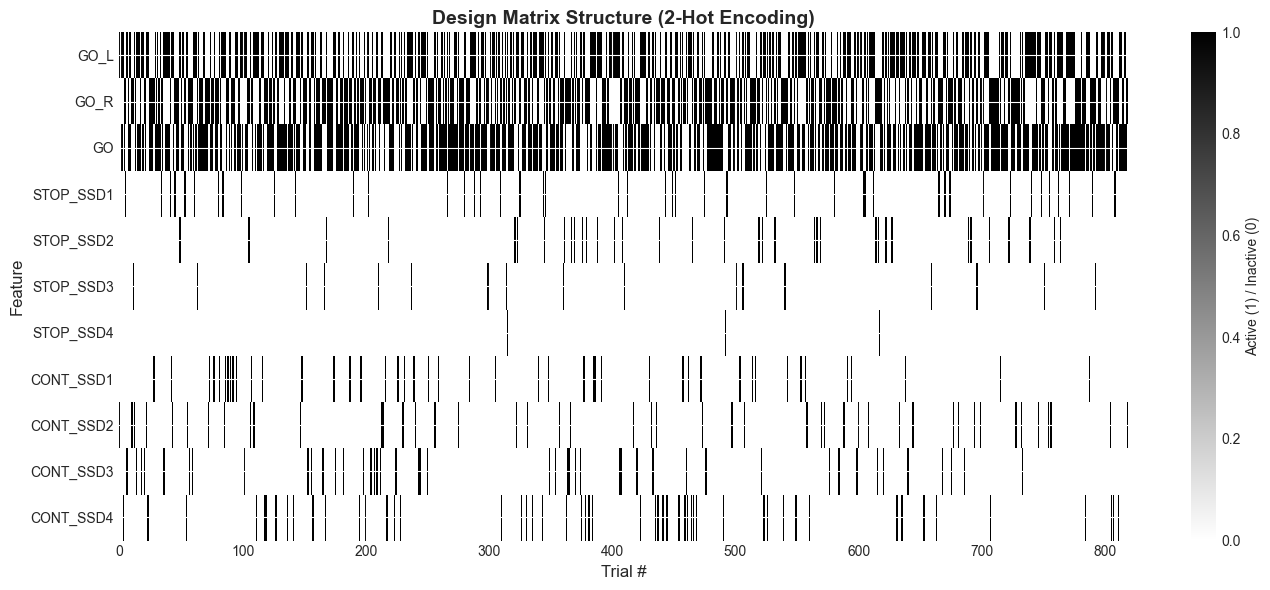

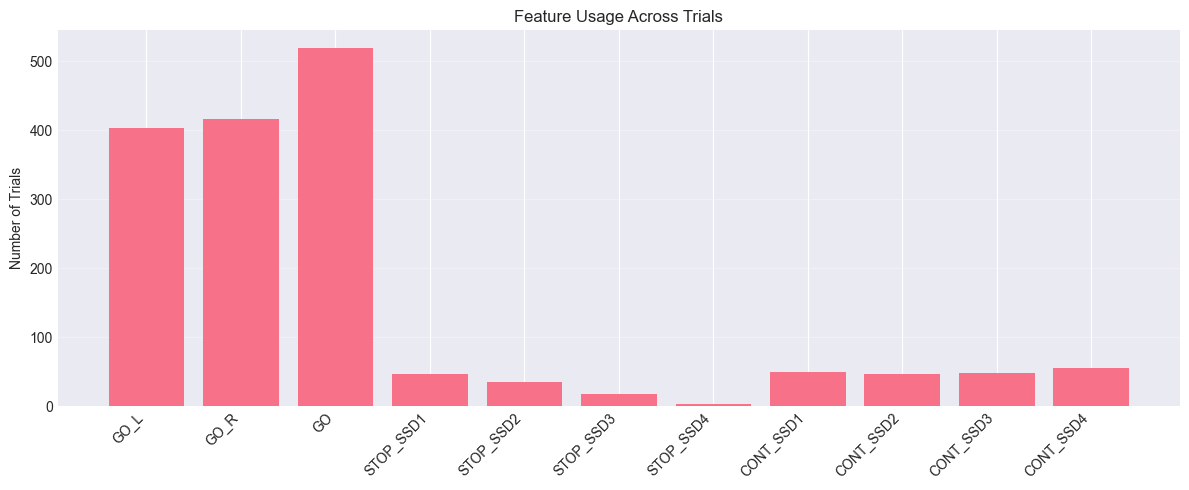

In [5]:
# Visualize design matrix structure
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(X.T, aspect='auto', cmap='binary', interpolation='nearest')
ax.set_xlabel('Trial #', fontsize=12)
ax.set_ylabel('Feature', fontsize=12)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names, fontsize=10)
ax.set_title('Design Matrix Structure (2-Hot Encoding)', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax, label='Active (1) / Inactive (0)')
plt.tight_layout()
plt.show()

# Show feature usage
feature_usage = X.sum(axis=0)
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(range(len(feature_names)), feature_usage)
ax.set_xticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_ylabel('Number of Trials')
ax.set_title('Feature Usage Across Trials')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Extract Response Variables

In [6]:
def sample_pseudo_ssd(session_data, random_state=None):
    """
    Sample pseudo-SSD for GO trials from empirical SSD distribution.
    """
    stop_trials = session_data[
        (session_data['type'] == 'STOP') & 
        (session_data['trial_failed'] == False)
    ]
    
    ssd_values = stop_trials['ssd_len'].dropna().values
    mean_ssd = np.mean(ssd_values)
    
    print(f"Pseudo-SSD for GO trials: {mean_ssd:.1f} ms (mean of STOP SSDs)")
    print(f"  Based on {len(ssd_values)} successful STOP trials")
    
    return mean_ssd

def extract_response_matrix(session, trial_info, config):
    """
    Extract spike counts for all cells in analysis window.
    """
    mean_ssd = sample_pseudo_ssd(session.data, config['random_state'])

    n_trials = len(trial_info)
    n_cells = session.n_cells
    Y = np.zeros((n_cells, n_trials))
    cell_ids = session.cell_ids

    print(f"\nExtracting responses for {n_cells} cells × {n_trials} trials...")

    trial_numbers = trial_info['trial_number'].values
    trial_types = trial_info['type'].values

    for cell_idx, cell_id in enumerate(tqdm(cell_ids, desc="Cells")):
        cell = session.get_cell(cell_id)
        cell_data_indexed = cell.data.set_index('trial_number')

        for trial_idx in range(n_trials):
            trial_num = trial_numbers[trial_idx]
            trial_type = trial_types[trial_idx]

            if trial_num not in cell_data_indexed.index:
                continue

            cell_trial = cell_data_indexed.loc[trial_num]

            # Determine cue2 time (stop_cue or pseudo for GO)
            if trial_type == 'GO':
                t_cue2 = cell_trial['go_cue'] + mean_ssd
            else:
                t_cue2 = cell_trial['stop_cue']

            # Extract spikes in window
            spikes = np.array(cell_trial['neural_data'])
            t_start = t_cue2 + config['epok'][0]
            t_end = t_cue2 + config['epok'][1]

            spike_count = np.sum((spikes >= t_start) & (spikes < t_end))
            Y[cell_idx, trial_idx] = spike_count

    print(f"✓ Response matrix: {Y.shape}")
    print(f"  Mean spike count: {Y.mean():.2f} ± {Y.std():.2f}")
    print(f"  Range: [{Y.min():.0f}, {Y.max():.0f}]")

    return Y, cell_ids

# Extract responses
Y, cell_ids = extract_response_matrix(session, trial_info, config)

Pseudo-SSD for GO trials: 93.6 ms (mean of STOP SSDs)
  Based on 3762 successful STOP trials

Extracting responses for 53 cells × 819 trials...


Cells: 100%|██████████| 53/53 [00:00<00:00, 53.80it/s]

✓ Response matrix: (53, 819)
  Mean spike count: 0.85 ± 1.72
  Range: [0, 18]


## 4. Fit Lasso Regression with Half-Split Stability

In [7]:
def fit_all_cells_parallel(X, Y, feature_names, config):
    """
    Fit regression for all cells using parallel processing.
    """
    n_cells, n_trials = Y.shape
    n_features = X.shape[1]
    
    betas = np.zeros((n_cells, n_features))
    betas_std = np.zeros((n_cells, n_features))
    
    n_workers = config.get('n_workers', max(1, mp.cpu_count() - 2))
    
    print(f"\nFitting Lasso regression for {n_cells} cells...")
    print(f"  {config['n_splits']} half-splits per cell")
    print(f"  {config['alpha_cv_folds']}-fold CV for alpha selection")
    print(f"  Using {n_workers} parallel workers")
    print("-" * 80)
    
    # Prepare arguments
    args_list = [
        (cell_idx, Y[cell_idx, :], X, config['n_splits'], 
         config['alpha_cv_folds'], config['random_state'])
        for cell_idx in range(n_cells)
    ]
    
    # Process in parallel
    with ProcessPoolExecutor(max_workers=n_workers) as executor:
        futures = {executor.submit(fit_single_cell_worker, args): args[0] 
                   for args in args_list}
        
        for future in tqdm(as_completed(futures), total=n_cells, desc="Fitting"):
            cell_idx, beta_mean, beta_std = future.result()
            betas[cell_idx, :] = beta_mean
            betas_std[cell_idx, :] = beta_std
    
    print(f"\n✓ Regression complete")
    print(f"  Non-zero coefficients: {(np.abs(betas) > 1e-6).sum()} / {betas.size}")
    print(f"  Sparsity: {100 * (np.abs(betas) < 1e-6).sum() / betas.size:.1f}%")
    
    return betas, betas_std

# Fit all cells
betas, betas_std = fit_all_cells_parallel(X, Y, feature_names, config)


Fitting Lasso regression for 53 cells...
  100 half-splits per cell
  5-fold CV for alpha selection
  Using 6 parallel workers
--------------------------------------------------------------------------------


Fitting:  77%|███████▋  | 41/53 [00:32<00:05,  2.20it/s]/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 0.000e+00, tolerance: 0.000e+00
  model = cd_fast.enet_coordinate_descent_gram(
/Users/barak/Projects/population_analysis/.conda/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did


✓ Regression complete
  Non-zero coefficients: 505 / 583
  Sparsity: 13.4%


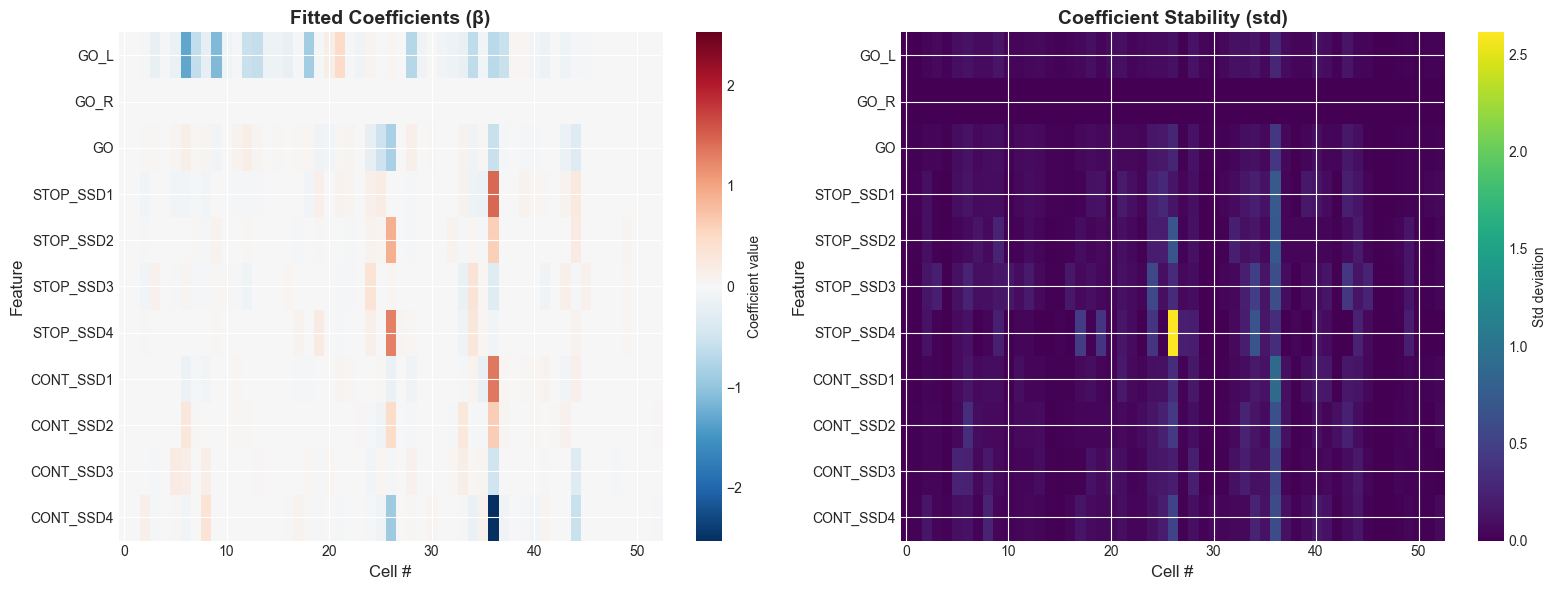

In [8]:
# Visualize coefficient matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mean coefficients
im1 = axes[0].imshow(betas.T, aspect='auto', cmap='RdBu_r', 
                     vmin=-np.abs(betas).max(), vmax=np.abs(betas).max())
axes[0].set_xlabel('Cell #', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].set_yticks(range(len(feature_names)))
axes[0].set_yticklabels(feature_names, fontsize=10)
axes[0].set_title('Fitted Coefficients (β)', fontsize=14, fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Coefficient value')

# Standard deviations
im2 = axes[1].imshow(betas_std.T, aspect='auto', cmap='viridis')
axes[1].set_xlabel('Cell #', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels(feature_names, fontsize=10)
axes[1].set_title('Coefficient Stability (std)', fontsize=14, fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Std deviation')

plt.tight_layout()
plt.show()

## 5. PCA on All Population Vectors Together

In [9]:
# Build population vectors (one per feature)
pop_vectors = {}
for feat_idx, feat_name in enumerate(feature_names):
    pop_vectors[feat_name] = betas[:, feat_idx]

print(f"✓ Built {len(pop_vectors)} population vectors")
print(f"  Each vector has {betas.shape[0]} dimensions (cells)")

# Stack all population vectors into matrix for PCA
pop_matrix = betas.T  # (n_features, n_cells)

print(f"\nPopulation matrix for PCA: {pop_matrix.shape}")
print(f"  Rows = features, Columns = cells")

✓ Built 11 population vectors
  Each vector has 53 dimensions (cells)

Population matrix for PCA: (11, 53)
  Rows = features, Columns = cells


In [10]:
# De-mean and perform PCA
pop_matrix_centered = pop_matrix - pop_matrix.mean(axis=0, keepdims=True)

pca = PCA(n_components=3)
projections = pca.fit_transform(pop_matrix_centered)  # (n_features, 3)

print(f"✓ PCA complete")
print(f"  Explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"    PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"    PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"    PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")

# Create mapping from feature name to projection
projections_dict = {}
for i, feat_name in enumerate(feature_names):
    projections_dict[feat_name] = projections[i, :]

✓ PCA complete
  Explained variance: 95.5%
    PC1: 57.6%
    PC2: 25.3%
    PC3: 12.7%


## 6. Visualize 3D Projections: GO and STOP SSD2 Trials

Focus on:
- GO trials (left and right)
- STOP SSD2 trials (left and right)

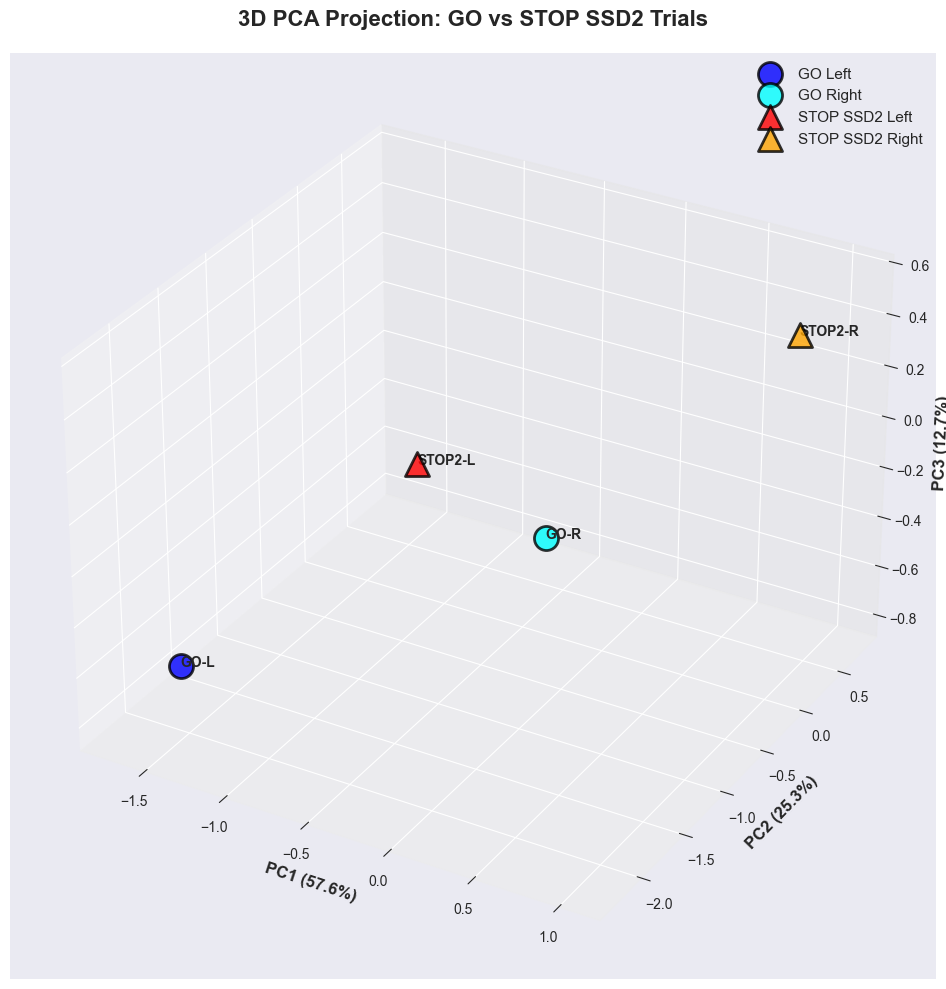

In [11]:
# Extract specific trial type projections
go_trials = ['GO']
stop_ssd2_trials = ['STOP_SSD2']
direction_features = ['GO_L', 'GO_R']

# Compute combined projections for trial conditions
# GO left = GO_L + GO
go_left_proj = projections_dict['GO_L'] + projections_dict['GO']
# GO right = GO_R + GO
go_right_proj = projections_dict['GO_R'] + projections_dict['GO']
# STOP SSD2 left = GO_L + STOP_SSD2
stop_ssd2_left_proj = projections_dict['GO_L'] + projections_dict['STOP_SSD2']
# STOP SSD2 right = GO_R + STOP_SSD2
stop_ssd2_right_proj = projections_dict['GO_R'] + projections_dict['STOP_SSD2']

# Create 3D plot
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot GO trials
ax.scatter(go_left_proj[0], go_left_proj[1], go_left_proj[2],
          c='blue', s=300, marker='o', edgecolors='black', linewidths=2,
          label='GO Left', alpha=0.8)
ax.scatter(go_right_proj[0], go_right_proj[1], go_right_proj[2],
          c='cyan', s=300, marker='o', edgecolors='black', linewidths=2,
          label='GO Right', alpha=0.8)

# Plot STOP SSD2 trials
ax.scatter(stop_ssd2_left_proj[0], stop_ssd2_left_proj[1], stop_ssd2_left_proj[2],
          c='red', s=300, marker='^', edgecolors='black', linewidths=2,
          label='STOP SSD2 Left', alpha=0.8)
ax.scatter(stop_ssd2_right_proj[0], stop_ssd2_right_proj[1], stop_ssd2_right_proj[2],
          c='orange', s=300, marker='^', edgecolors='black', linewidths=2,
          label='STOP SSD2 Right', alpha=0.8)

# Add text labels
ax.text(go_left_proj[0], go_left_proj[1], go_left_proj[2], 'GO-L', 
        fontsize=10, fontweight='bold')
ax.text(go_right_proj[0], go_right_proj[1], go_right_proj[2], 'GO-R',
        fontsize=10, fontweight='bold')
ax.text(stop_ssd2_left_proj[0], stop_ssd2_left_proj[1], stop_ssd2_left_proj[2], 'STOP2-L',
        fontsize=10, fontweight='bold')
ax.text(stop_ssd2_right_proj[0], stop_ssd2_right_proj[1], stop_ssd2_right_proj[2], 'STOP2-R',
        fontsize=10, fontweight='bold')

# Formatting
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('3D PCA Projection: GO vs STOP SSD2 Trials', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualize All Features in 3D Space

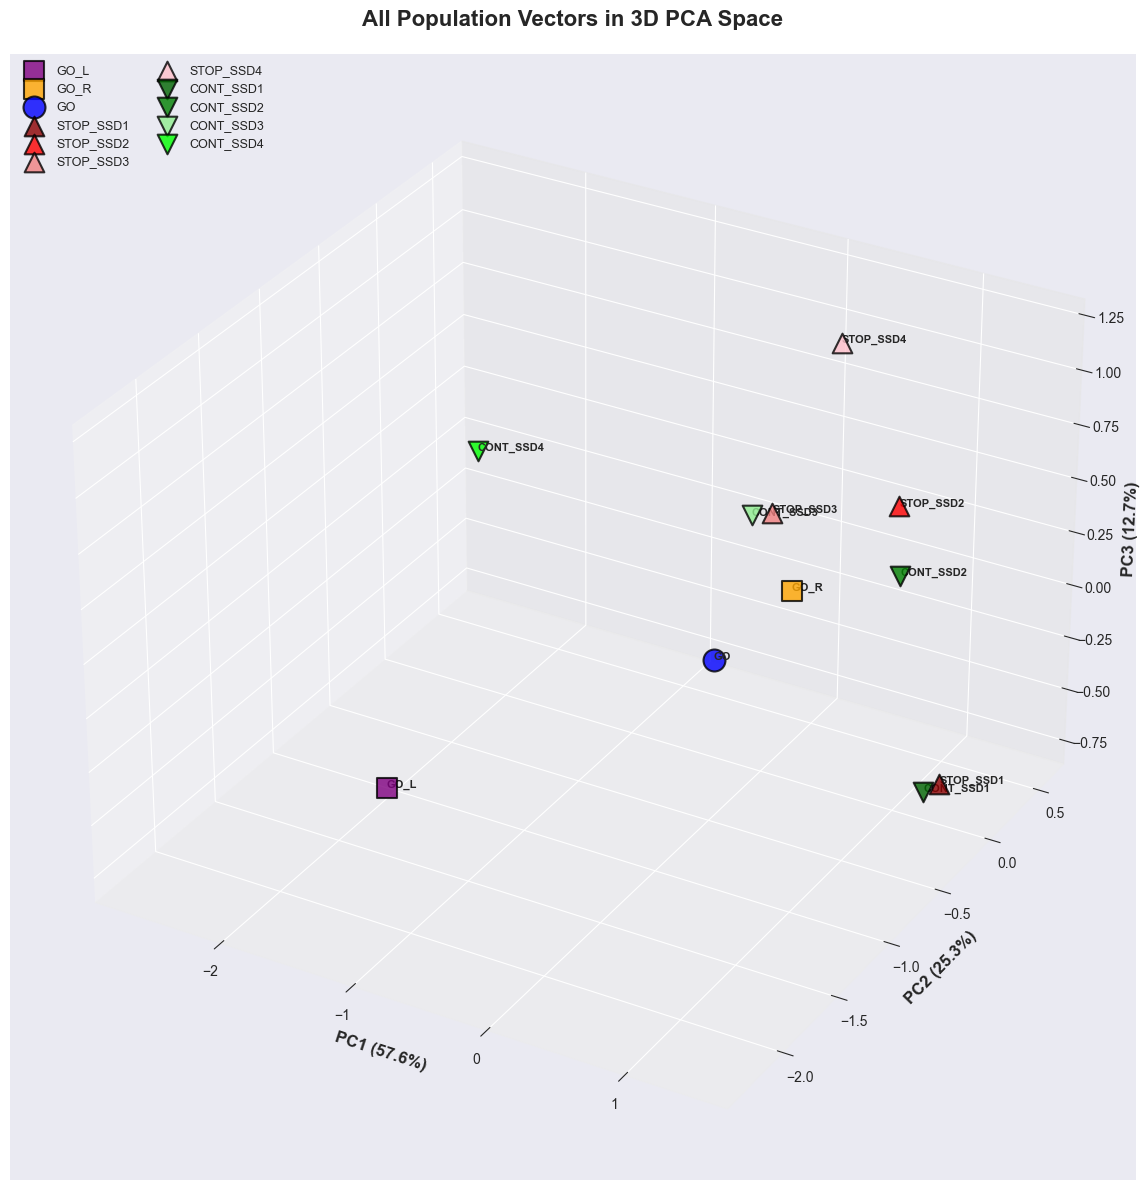

In [12]:
# Plot all population vectors in 3D
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Color scheme
colors = {
    'GO_L': 'purple',
    'GO_R': 'orange',
    'GO': 'blue',
}

# Add STOP colors
stop_colors = ['darkred', 'red', 'lightcoral', 'pink']
for i, ssd in enumerate([1, 2, 3, 4]):
    colors[f'STOP_SSD{ssd}'] = stop_colors[i]

# Add CONT colors
cont_colors = ['darkgreen', 'green', 'lightgreen', 'lime']
for i, ssd in enumerate([1, 2, 3, 4]):
    colors[f'CONT_SSD{ssd}'] = cont_colors[i]

# Plot each feature
for feat_name in feature_names:
    proj = projections_dict[feat_name]
    color = colors.get(feat_name, 'gray')
    
    if 'GO_' in feat_name:  # Direction features
        marker = 's'
        size = 200
    elif 'GO' == feat_name:  # GO trial type
        marker = 'o'
        size = 250
    elif 'STOP' in feat_name:
        marker = '^'
        size = 200
    else:  # CONT
        marker = 'v'
        size = 200
    
    ax.scatter(proj[0], proj[1], proj[2], c=color, s=size, marker=marker,
              edgecolors='black', linewidths=1.5, alpha=0.8, label=feat_name)
    
    # Add label
    ax.text(proj[0], proj[1], proj[2], feat_name, fontsize=8, fontweight='bold')

# Formatting
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('All Population Vectors in 3D PCA Space', fontsize=16, fontweight='bold', pad=20)
ax.legend(fontsize=9, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Summary Statistics

In [13]:
print("="*80)
print("SIMPLE 2-HOT ENCODING ANALYSIS SUMMARY")
print("="*80)
print(f"\nSession: {config['session_id']}")
print(f"Cells analyzed: {len(cell_ids)}")
print(f"Trials (successful only): {len(trial_info)}")
print(f"\nRegression:")
print(f"  Features: {len(feature_names)}")
print(f"    Direction: GO_L, GO_R")
print(f"    Trial types: GO, STOP_SSD1-4, CONT_SSD1-4")
print(f"  Half-splits: {config['n_splits']}")
print(f"  Sparsity: {100 * (np.abs(betas) < 1e-6).sum() / betas.size:.1f}%")
print(f"\nPCA:")
print(f"  Total variance explained (3 PCs): {pca.explained_variance_ratio_.sum()*100:.1f}%")
print(f"    PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"    PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"    PC3: {pca.explained_variance_ratio_[2]*100:.1f}%")
print("="*80)

SIMPLE 2-HOT ENCODING ANALYSIS SUMMARY

Session: fi211115a
Cells analyzed: 53
Trials (successful only): 819

Regression:
  Features: 11
    Direction: GO_L, GO_R
    Trial types: GO, STOP_SSD1-4, CONT_SSD1-4
  Half-splits: 100
  Sparsity: 13.4%

PCA:
  Total variance explained (3 PCs): 95.5%
    PC1: 57.6%
    PC2: 25.3%
    PC3: 12.7%


## 9. Save Results

In [14]:
# Save results
output_dir = Path('../../data/simple_encoding_results')
output_dir.mkdir(parents=True, exist_ok=True)

# Save coefficients
np.save(output_dir / f"{config['session_id']}_betas.npy", betas)
np.save(output_dir / f"{config['session_id']}_betas_std.npy", betas_std)

# Save PCA results
np.save(output_dir / f"{config['session_id']}_pca_projections.npy", projections)
np.save(output_dir / f"{config['session_id']}_pca_components.npy", pca.components_)
np.save(output_dir / f"{config['session_id']}_pca_variance.npy", pca.explained_variance_ratio_)

# Save metadata
import json
metadata = {
    'session_id': config['session_id'],
    'n_cells': len(cell_ids),
    'n_trials': len(trial_info),
    'n_features': len(feature_names),
    'feature_names': feature_names,
    'config': config
}

with open(output_dir / f"{config['session_id']}_metadata.json", 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Results saved to: {output_dir}")

✓ Results saved to: ../../data/simple_encoding_results
